## Imports

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
import shap
import pandas as pd
from sklearn.model_selection import train_test_split

In [19]:
# Load data
diabetes = pd.read_csv("data/diabetes_processed.csv")
ids = pd.read_csv("data/diabetes/IDS_mapping.csv")

In [20]:
target_name = 'readmitted'

X = diabetes[[c for c in diabetes if c != target_name]].copy()
y = diabetes[target_name].copy()

# Protected attribute for fairness analysis
group = diabetes["gender"].astype(int)

X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    X,
    y,
    group,
    test_size=0.2,
    random_state=0,
    stratify=y
)

In [21]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 55989 entries, 62192 to 5861
Data columns (total 84 columns):
 #   Column                                          Non-Null Count  Dtype
---  ------                                          --------------  -----
 0   gender                                          55989 non-null  int64
 1   age                                             55989 non-null  int64
 2   time_in_hospital                                55989 non-null  int64
 3   num_lab_procedures                              55989 non-null  int64
 4   num_procedures                                  55989 non-null  int64
 5   num_medications                                 55989 non-null  int64
 6   number_diagnoses                                55989 non-null  int64
 7   metformin                                       55989 non-null  int64
 8   repaglinide                                     55989 non-null  int64
 9   nateglinide                                     55989 non-null  int64
 10 

In [22]:
def print_classification_results(y_test, y_pred):
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print('Classification Report:')
    print(classification_report(y_test, y_pred))

In [23]:
def get_log_reg_pipeline(
    seed: int = 70766,
    max_iter: int = 5000,
    penalty: str = 'l2',
    C: float = 0.8497534359086438,
    tol: float = 1e-4,
    solver: str = 'saga'
):
    scaler = StandardScaler() # Standard scale for log reg
    model = LogisticRegression(
        class_weight='balanced',
        penalty = penalty,
        C = C,
        random_state = seed,
        max_iter = max_iter,
        tol = tol,
        solver = solver
    )
    pipeline = Pipeline([('scaler', scaler), ('classifier', model)])
    return pipeline

In [24]:
# Get pipeline and fit to training data
log_reg = get_log_reg_pipeline()
log_reg.fit(X_train, y_train)

# Predict on test set
log_reg_y_pred = log_reg.predict(X_test)

# Evaluate
print_classification_results(y_test, log_reg_y_pred)

c:\Users\kubic\OneDrive\Dokumenty\envs\algotithmic_fairness\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy: 0.6277
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.64      0.76     12741
           1       0.13      0.54      0.21      1257

    accuracy                           0.63     13998
   macro avg       0.53      0.59      0.48     13998
weighted avg       0.86      0.63      0.71     13998



In [25]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, log_reg_y_pred))

[[8102 4639]
 [ 573  684]]


In [26]:
def get_scores_test(model, X_test):
    return model.predict_proba(X_test)[:, 1]

def make_selection(scores_test, thresholds: tuple = (.5, .5)):
    # Apply group-specific thresholds
    selections = np.zeros_like(scores_test)
    selections[group_test == 0] = (scores_test[group_test == 0] >= thresholds[0]).astype(int)
    selections[group_test == 1] = (scores_test[group_test == 1] >= thresholds[1]).astype(int)
    return selections

# Define function to evaluate fairness
def evaluate_fairness(S, T, G):
    df = pd.DataFrame({'S': S, 'T': T, 'G': G})

    results = {}
    for g in [0, 1]: # Male, Female
        subset = df[df['G'] == g]

        # Statistical/demographic parity P(S=1|G)
        results[f'G={g}_Selection_Rate'] = subset['S'].mean()

        # Equalized Odds P(S=1|G, T)
        results[f'G={g}_TPR'] = subset[subset['T'] == 1]['S'].mean()
        results[f'G={g}_FPR'] = subset[subset['T'] == 0]['S'].mean()

        # Equalized Outcome P(T=1|G, S)
        results[f'G={g}_Prec'] = subset[subset['S'] == 1]['T'].mean()
        results[f'G={g}_NPV'] = subset[subset['S'] == 0]['T'].mean()

    return results

def print_fairness_overiew(fairness_metrics: dict, epsilon: float = 1e-3):
    # Statistical parity
    print('Statistical Parity:')
    g1_selection_rate = fairness_metrics['G=0_Selection_Rate']
    g2_selection_rate = fairness_metrics['G=1_Selection_Rate']
    print(f'Group 0 Selection Rate P(S=1|G=0): {g1_selection_rate:.4f}')
    print(f'Group 1 Selection Rate P(S=1|G=1): {g2_selection_rate:.4f}')
    if abs(g1_selection_rate - g2_selection_rate) < epsilon:
        print('Statistical parity (approximately) achieved.')
    else:
        print('Statistical parity not achieved.')
    print('')

    # Equalized Odds
    print('Equalized Odds:')
    g0_tpr = fairness_metrics['G=0_TPR']
    g1_tpr = fairness_metrics['G=1_TPR']
    g0_fpr = fairness_metrics['G=0_FPR']
    g1_fpr = fairness_metrics['G=1_FPR']

    print(f'Group 0 True Positive Rate P(S=1|G=0,T=1): {g0_tpr:.4f}')
    print(f'Group 1 True Positive Rate P(S=1|G=1,T=1): {g1_tpr:.4f}')

    print(f'Group 0 False Positive Rate P(S=1|G=0,T=0): {g0_fpr:.4f}')
    print(f'Group 1 False Positive Rate P(S=1|G=1,T=0): {g1_fpr:.4f}')
    if abs(g0_tpr - g1_tpr) < epsilon and abs(g0_fpr - g1_fpr) < epsilon:
        print('Equalized odds (approximately) achieved.')
    else:
        print('Equalized odds not achieved.')

def plot_fairness_metrics(fairness_metrics: dict, scores_test, roc_cross: tuple = None):
    _, axes = plt.subplots(1, 2, figsize = (12, 6))

    # ROC curve
    for g, label in zip([0, 1], ['Group 0', 'Group 1']):
        idx = group_test == g
        fpr, tpr, _ = roc_curve(y_test[idx], scores_test[idx])
        axes[0].plot(fpr, tpr, label=label)

    if roc_cross is not None:
        axes[0].scatter([roc_cross[0]], [roc_cross[1]], marker = 'x', color = 'red', s = 100)

    axes[0].grid(True, linestyle = '--')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve by Group')
    axes[0].legend()

    # Bar plot
    groups = ['Group 0', 'Group 1']
    selection_rates = [fairness_metrics['G=0_Selection_Rate'], fairness_metrics['G=1_Selection_Rate']]
    axes[1].bar(groups, selection_rates)
    axes[1].set_ylabel('Selection Rate')
    axes[1].set_title('Selection Rate by Group')
    plt.show()

Statistical Parity:
Group 0 Selection Rate P(S=1|G=0): 0.3817
Group 1 Selection Rate P(S=1|G=1): 0.3786
Statistical parity not achieved.

Equalized Odds:
Group 0 True Positive Rate P(S=1|G=0,T=1): 0.5298
Group 1 True Positive Rate P(S=1|G=1,T=1): 0.5607
Group 0 False Positive Rate P(S=1|G=0,T=0): 0.3670
Group 1 False Positive Rate P(S=1|G=1,T=0): 0.3608
Equalized odds not achieved.


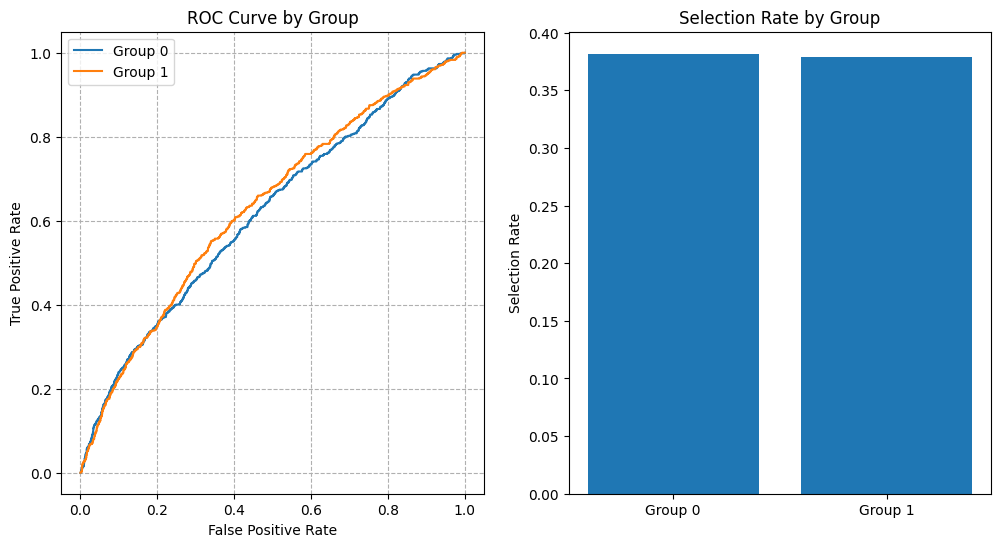

In [27]:
# Get test scores and make selections
log_reg_scores_test = get_scores_test(log_reg, X_test)
log_reg_selections = make_selection(log_reg_scores_test)
log_reg_fairness_metrics = evaluate_fairness(log_reg_selections, y_test, group_test)
print_fairness_overiew(log_reg_fairness_metrics)
plot_fairness_metrics(log_reg_fairness_metrics, log_reg_scores_test)

NEED TO FIGURE OUT IF WE SHOULD COMPUTE FAIRNESS METRICS ALSO FOR RACES!!

In [28]:
race_columns = [
    "race_Asian",
    "race_Caucasian",
    "race_Hispanic",
    "race_Other"
]

def get_race(row):
    if row["race_Asian"] == 1:
        return "Asian"
    elif row["race_Caucasian"] == 1:
        return "Caucasian"
    elif row["race_Hispanic"] == 1:
        return "Hispanic"
    elif row["race_Other"] == 1:
        return "Other"
    else:
        return "AfricanAmerican"

race_test = X_test.apply(get_race, axis=1)

Beeswarm plot of SHAP values showing the contribution of the most important features to the prediction (Top 10 values)

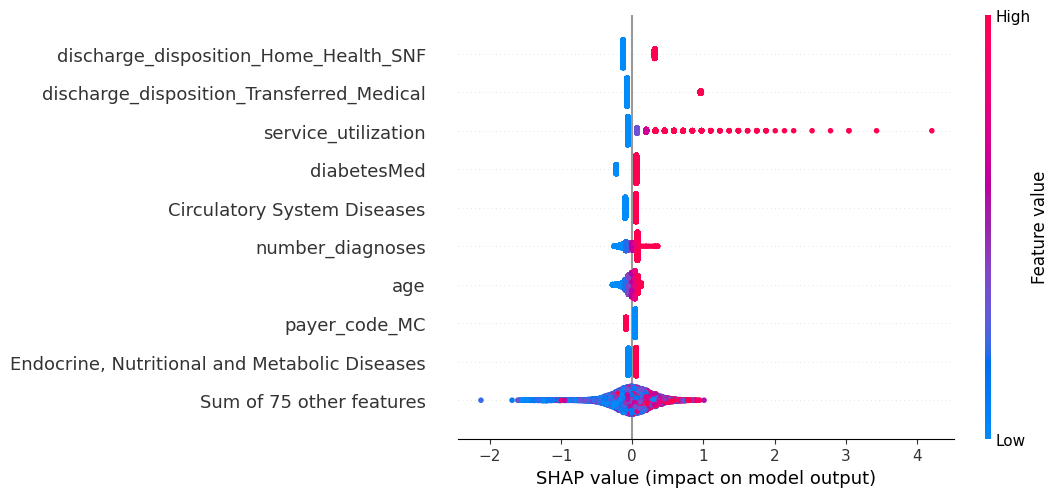

In [29]:
scaler = log_reg.named_steps["scaler"]
clf_lr = log_reg.named_steps["classifier"]

# Scaleing train and test data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)


explainer = shap.Explainer(clf_lr, X_train_scaled_df)
shap_values = explainer(X_test_scaled_df)
shap.plots.beeswarm(shap_values, max_display=10)

All values 

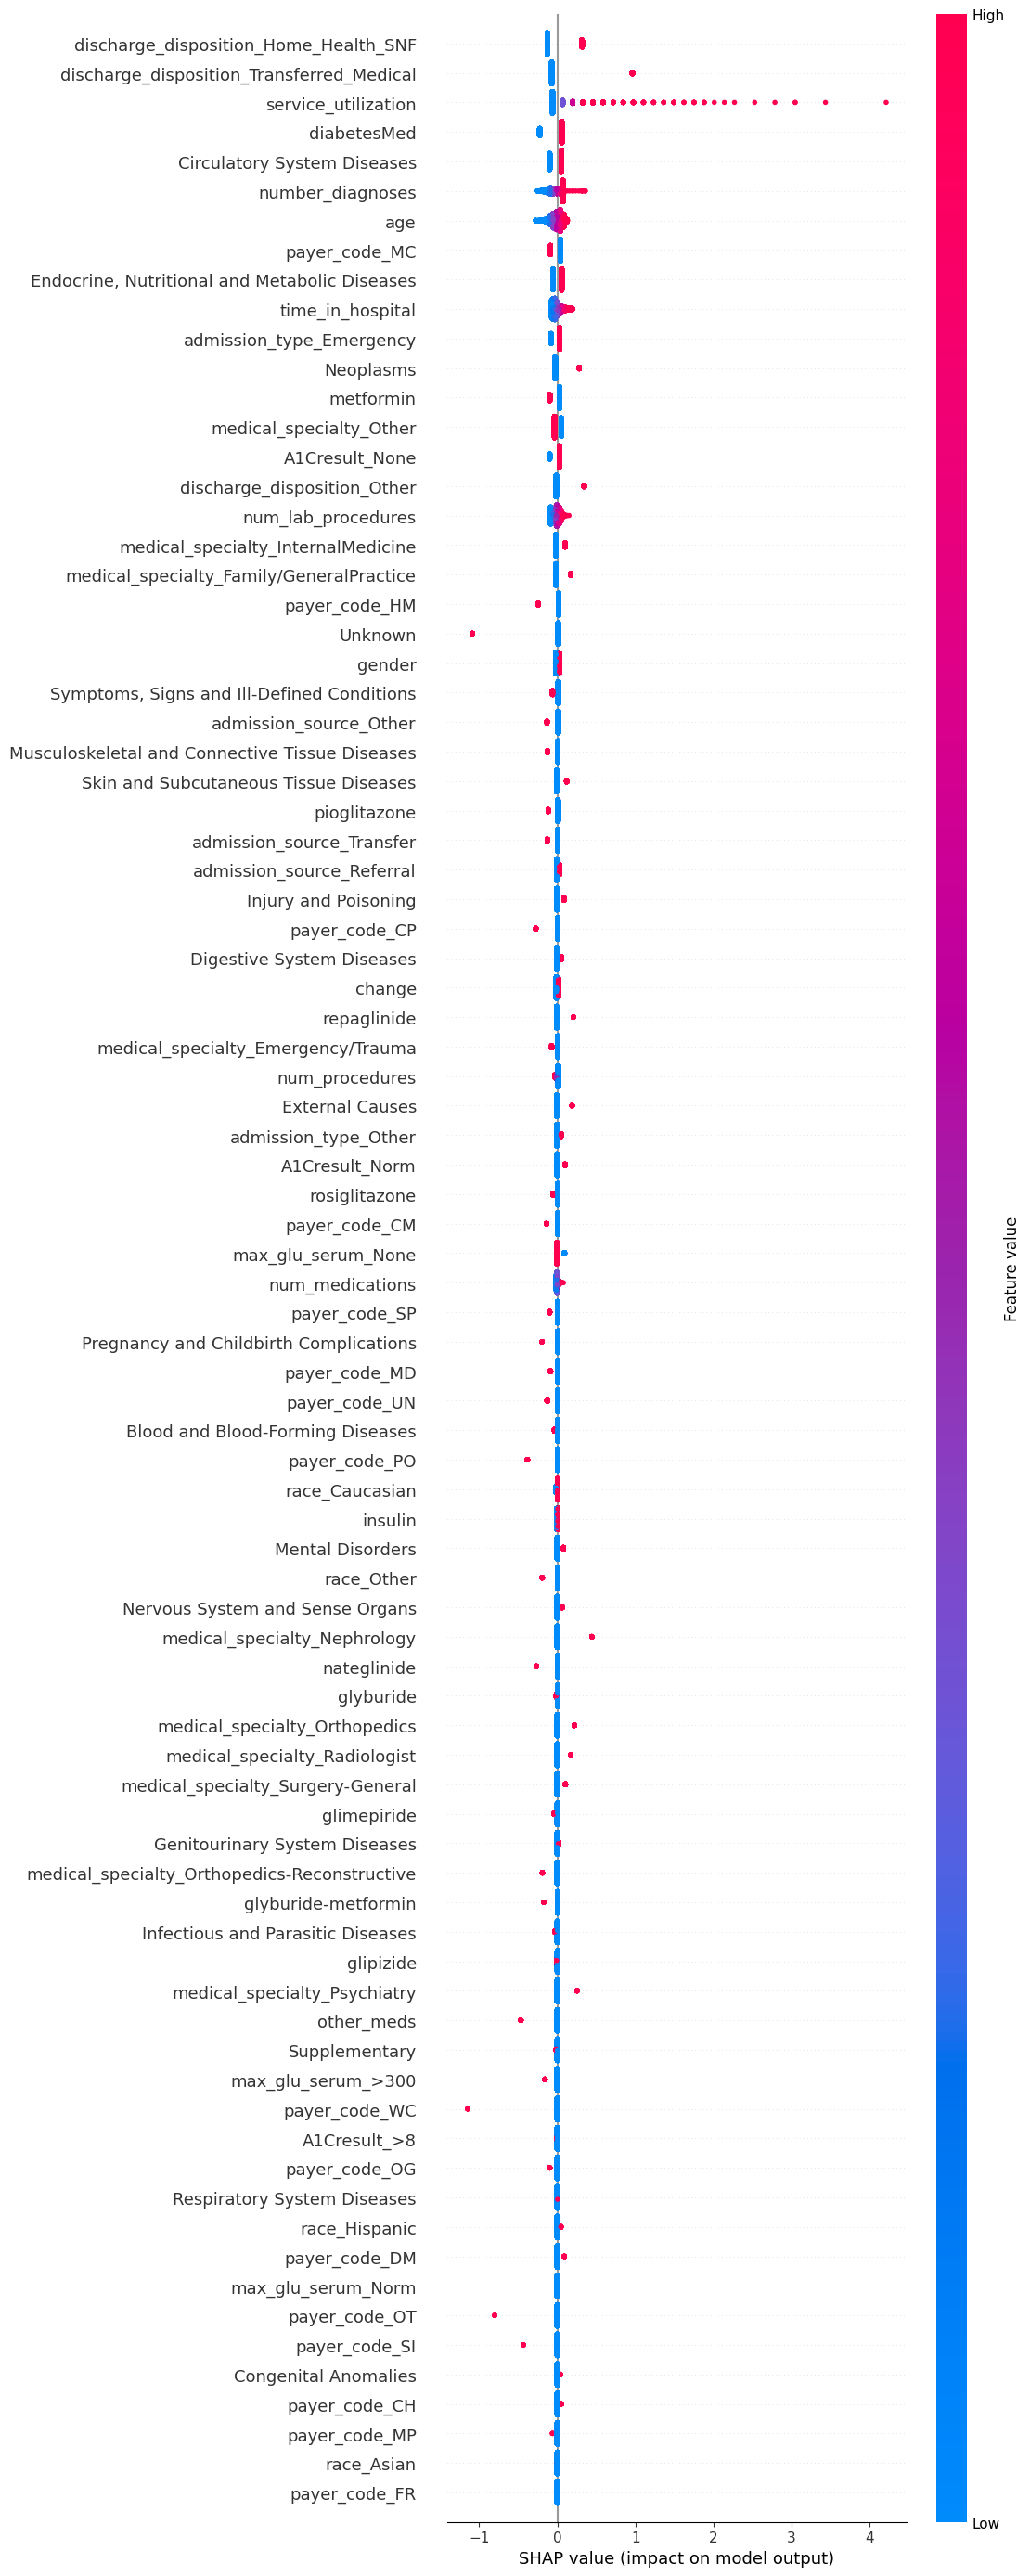

In [30]:
shap.plots.beeswarm(shap_values, max_display=len(X_train.columns))

Beeswarm plot showing our sensitive features of interest

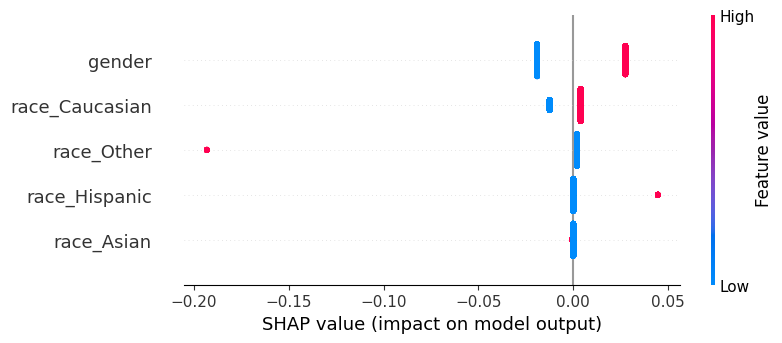

In [31]:
sensitive_features = [
    "gender",
    "race_Asian",
    "race_Caucasian",
    "race_Hispanic",
    "race_Other"
]

# Get column indices of sensitive features
sensitive_idx = [
    list(X_train.columns).index(col)
    for col in sensitive_features
]

# Creating SHAP values for only sensitive features
sensitive_shap = shap_values[:, sensitive_idx]
shap.plots.beeswarm(sensitive_shap)

Mean absolute SHAP values for the demografic features

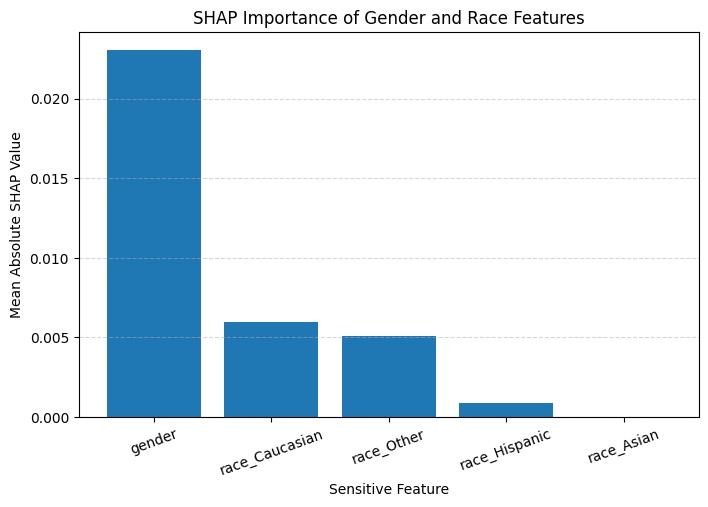

In [32]:
sensitive_features = [
    "gender",
    "race_Asian",
    "race_Caucasian",
    "race_Hispanic",
    "race_Other"
]

# Computing mean absolute SHAP values
mean_shap = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "mean_abs_shap": mean_shap
})

# Keeping only sensitive features
protected_importance = importance_df[
    importance_df["feature"].isin(sensitive_features)
].sort_values("mean_abs_shap", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(
    protected_importance["feature"],
    protected_importance["mean_abs_shap"]
)
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Sensitive Feature")
plt.title("SHAP Importance of Gender and Race Features")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

Local SHAP explanation for one prediction

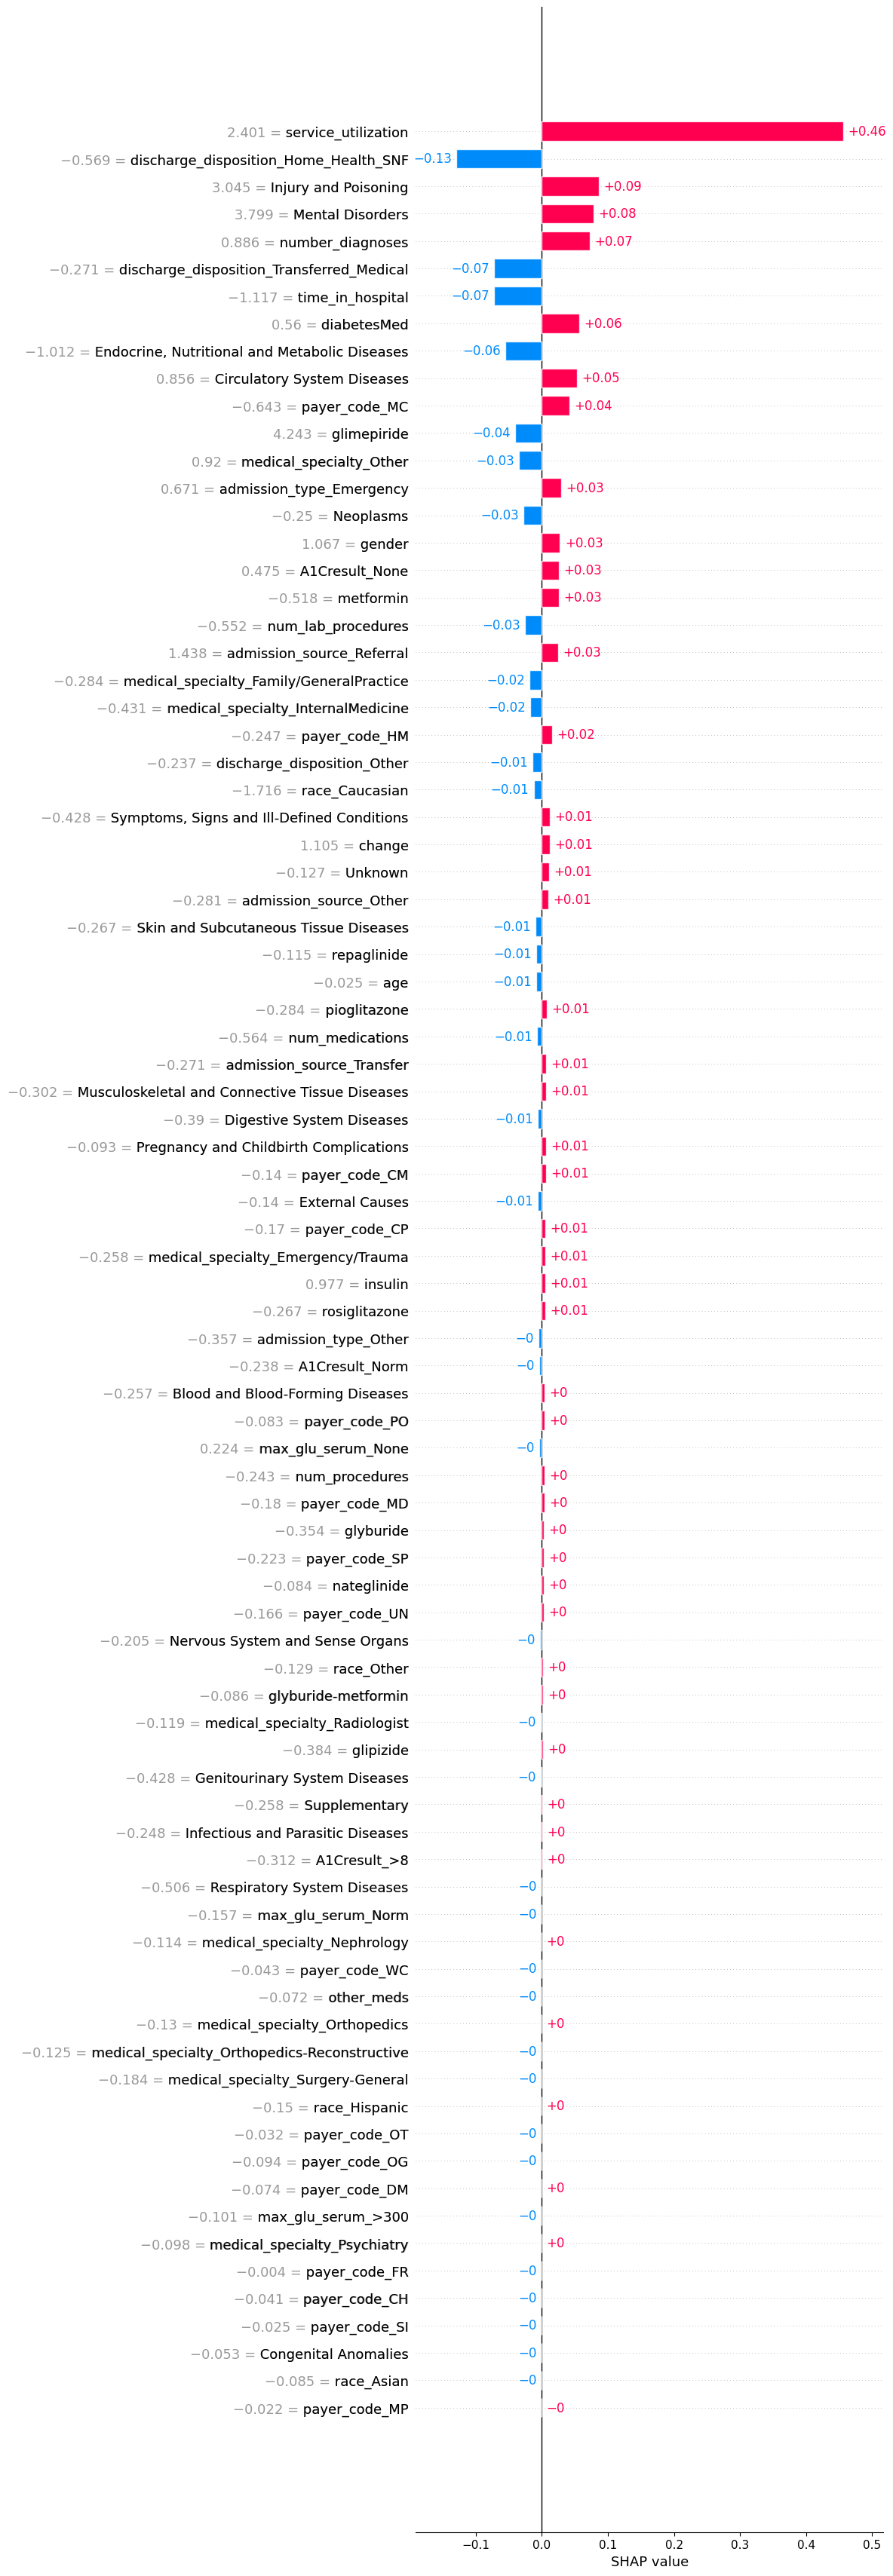

In [33]:
feature_names = X_train.columns
explainer_lr = shap.LinearExplainer(clf_lr, X_train_scaled,feature_names=feature_names)
shap_values_lr = explainer_lr(X_test_scaled)

shap.plots.bar(shap_values_lr[20],max_display=len(X_train.columns))

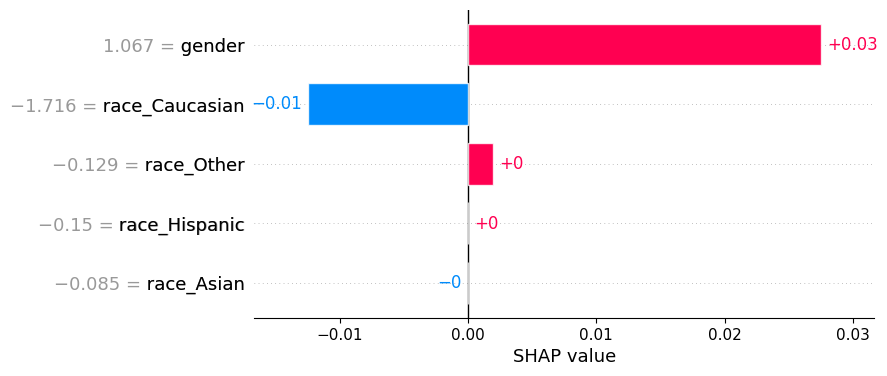

In [34]:
sensitive_shap_values = shap_values_lr[:, sensitive_idx]
shap.plots.bar(
    sensitive_shap_values[20],
    max_display=len(sensitive_features)
)

Checking what demography the patient is and since all race columns have value 0, the patient is AfricanAmerican

In [35]:
X_test.iloc[20][[
    "race_Asian",
    "race_Caucasian",
    "race_Hispanic",
    "race_Other"
]]

race_Asian        0
race_Caucasian    0
race_Hispanic     0
race_Other        0
Name: 40809, dtype: int64